### Google Net

In [3]:
# 构建依赖
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import time
import random

In [4]:
# data prepare
batch_size = 64
transform = transforms.Compose([transforms.ToTensor(), 
                                transforms.Normalize((0.1307,), (0.3081,))])
# 训练集
train_dataset = datasets.MNIST(root='./dataset/mnist', train=True, download=False, transform=transform)
# 测试集
test_dataset = datasets.MNIST(root='./dataset/mnist', train=False, download=False, transform=transform)
# 数据加载器
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

print(f"size of train_loader: {train_loader.dataset.data.size()}")
print(f"size of test_loader: {test_loader.dataset.data.size()}")

size of train_loader: torch.Size([60000, 28, 28])
size of test_loader: torch.Size([10000, 28, 28])


In [10]:
# model design
class InceptionA(torch.nn.Module):
    '''
    InceptionA模块指GoogleNet网络中的一个模块, 包含四个分支, 其中的网络层有:
    1*1 卷积层、3*3 卷积层、5*5 卷积层、池化层
    '''
    def __init__(self, in_channels):
        super(InceptionA, self).__init__()
        self.branch1x1 = torch.nn.Conv2d(in_channels, 16, kernel_size=1)

        self.branch5x5_1 = torch.nn.Conv2d(in_channels, 16, kernel_size=1)
        self.branch5x5_2 = torch.nn.Conv2d(16, 24, kernel_size=5, padding=2)
        
        self.branch3x3_1 = torch.nn.Conv2d(in_channels, 16, kernel_size=1)
        self.branch3x3_2 = torch.nn.Conv2d(16, 24, kernel_size=3, padding=1)
        self.branch3x3_3 = torch.nn.Conv2d(24, 24, kernel_size=3, padding=1)
        
        self.branch_pool = torch.nn.Conv2d(in_channels, 24, kernel_size=1)

    def forward(self, x):
        branch1x1 = self.branch1x1(x)

        branch5x5 = self.branch5x5_1(x)
        branch5x5 = self.branch5x5_2(branch5x5)

        branch3x3 = self.branch3x3_1(x)
        branch3x3 = self.branch3x3_2(branch3x3)
        branch3x3 = self.branch3x3_3(branch3x3)

        branch_pool = F.avg_pool2d(x, kernel_size=3, stride=1, padding=1)    # 池化层, 池化核大小为3*3, 步长为1, 填充为1
        branch_pool = self.branch_pool(branch_pool)

        outputs = [branch1x1, branch5x5, branch3x3, branch_pool]    # 将四个分支输出的结果合并为列表
        return torch.cat(outputs, dim=1)    # 然后在通道维度上进行拼接

class Net(torch.nn.Module):
    '''
    定义一个包含InceptionA模块的网络
    '''
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = torch.nn.Conv2d(1, 10, kernel_size=5)
        self.conv2 = torch.nn.Conv2d(88, 20, kernel_size=5)

        self.inceptiona_1 = InceptionA(in_channels=10)
        self.inceptiona_2 = InceptionA(in_channels=20)

        self.mp = torch.nn.MaxPool2d(2, 2)
        self.fc = torch.nn.Linear(1408, 10)

    def forward(self, x):
        in_size = x.size(0)
        x = F.relu(self.mp(self.conv1(x)))
        x = self.inceptiona_1(x)
        x = F.relu(self.mp(self.conv2(x)))
        x = self.inceptiona_2(x)
        x = x.view(in_size, -1)
        x = self.fc(x)
        return x

model = Net()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

Net(
  (conv1): Conv2d(1, 10, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(88, 20, kernel_size=(5, 5), stride=(1, 1))
  (inceptiona_1): InceptionA(
    (branch1x1): Conv2d(10, 16, kernel_size=(1, 1), stride=(1, 1))
    (branch5x5_1): Conv2d(10, 16, kernel_size=(1, 1), stride=(1, 1))
    (branch5x5_2): Conv2d(16, 24, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (branch3x3_1): Conv2d(10, 16, kernel_size=(1, 1), stride=(1, 1))
    (branch3x3_2): Conv2d(16, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (branch3x3_3): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (branch_pool): Conv2d(10, 24, kernel_size=(1, 1), stride=(1, 1))
  )
  (inceptiona_2): InceptionA(
    (branch1x1): Conv2d(20, 16, kernel_size=(1, 1), stride=(1, 1))
    (branch5x5_1): Conv2d(20, 16, kernel_size=(1, 1), stride=(1, 1))
    (branch5x5_2): Conv2d(16, 24, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (branch3x3_1): Conv2d(20, 16, kernel_size=(1, 1), stride

In [11]:
# loss and optimizer
criterion = torch.nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.5)

In [12]:
# train cycle
def train(epoch):
    model.train()
    running_loss = 0.0    # 用于每200个batch打印
    epoch_loss = 0.0      # 用于记录整个epoch平均loss
    num_batches = 0
    train_correct = 0
    train_total = 0

    for batch_idx, data in enumerate(train_loader, 0):
        '''
        batch_idx 是当前批次索引, data 是当前批次的数据和标签
        (train_loader, 0) 表示从train_loader中获取数据, 从0开始计数
        '''
        inputs, labels = data    # 获取当前循环的索引批次对应的输入数据和标签
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()    # 每一次循环开始时，先进行梯度清零

        outputs = model(inputs)    # 将输入数据传入模型Net，得到输出
        loss = criterion(outputs, labels)    # 损失函数计算
        loss.backward()    # 计算完损失函数后，进行反向传播, 计算梯度
        optimizer.step()    # 计算完梯度后，进行参数更新

        running_loss += loss.item()    # 损失值累加到running_loss中
        epoch_loss += loss.item()
        num_batches += 1

        _, predicted = torch.max(outputs.data, dim=1)
        train_total += labels.size(0)    # 获取标签的数量作为训练的总数量
        train_correct += (predicted == labels).sum().item()

        # 每200个批次打印一次损失，查看依次训练的损失
        if batch_idx % 200 == 199:
            print(f"[epoch {epoch + 1}, batch {batch_idx + 1}] loss: {running_loss / 200}")
            running_loss = 0.0

    avg_train_loss = epoch_loss / num_batches
    train_losses.append(avg_train_loss)
    train_accs.append(100 * train_correct / train_total)

In [13]:
# test
def test():
    '''
    return: 预测结果
    '''
    model.eval()
    correct = 0.0
    total = 0.0
    test_loss = 0.0
    num_batches = 0    # 记录测试集的批次数量

    with torch.no_grad():    # 推理阶段不需要计算梯度
        for data in test_loader:    # 获取测试集中的数据，数据由28*28的灰度图像和对应的标签组成
            images, labels = data
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            loss = criterion(outputs, labels)
            test_loss += loss.item()
            num_batches += 1

            # 获取输出中最大概率的索引
            # dim = 1 沿着列的方向取最大值，即按行取最大值，即从第一行开始，取每一行的所有列中列的最大值
            # 返回最大值的索引和最大值
            _, predicted = torch.max(outputs.data, dim=1)
            total += labels.size(0)    # 获取标签的数量
            correct += (predicted == labels).sum().item()    # 计算预测正确的数量

    avg_test_loss = test_loss / num_batches
    avg_test_acc = 100 * correct / total
    test_losses.append(avg_test_loss)
    test_accs.append(avg_test_acc)
    print(f"Accuracy of the network on the 10000 test images: {avg_test_acc}%")

[epoch 1, batch 200] loss: 1.1349571330100299
[epoch 1, batch 400] loss: 0.27361868515610693
[epoch 1, batch 600] loss: 0.19676429191604256
[epoch 1, batch 800] loss: 0.1525590860284865
Accuracy of the network on the 10000 test images: 96.73%
[epoch 2, batch 200] loss: 0.1204713454283774
[epoch 2, batch 400] loss: 0.10973583407700062
[epoch 2, batch 600] loss: 0.09791338222566992
[epoch 2, batch 800] loss: 0.0925157207576558
Accuracy of the network on the 10000 test images: 97.77%
[epoch 3, batch 200] loss: 0.08428529773838818
[epoch 3, batch 400] loss: 0.07865704134805128
[epoch 3, batch 600] loss: 0.07261446379707195
[epoch 3, batch 800] loss: 0.07742319646757095
Accuracy of the network on the 10000 test images: 98.12%
[epoch 4, batch 200] loss: 0.0670330751570873
[epoch 4, batch 400] loss: 0.06171234158682637
[epoch 4, batch 600] loss: 0.05988738808315247
[epoch 4, batch 800] loss: 0.06996170934056863
Accuracy of the network on the 10000 test images: 98.51%
[epoch 5, batch 200] loss

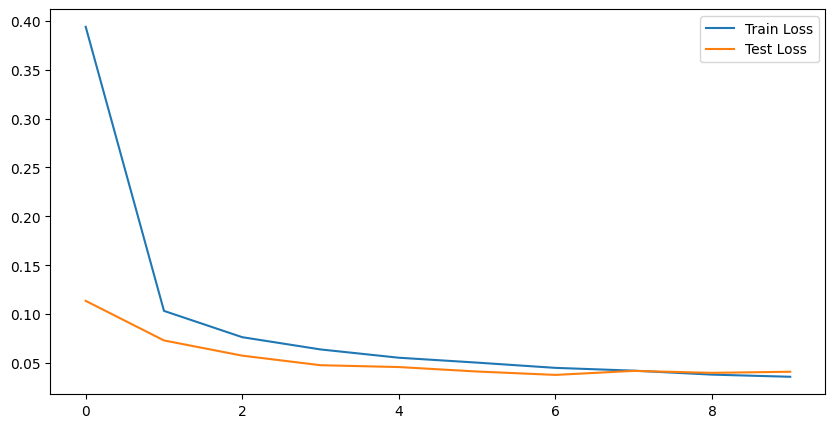

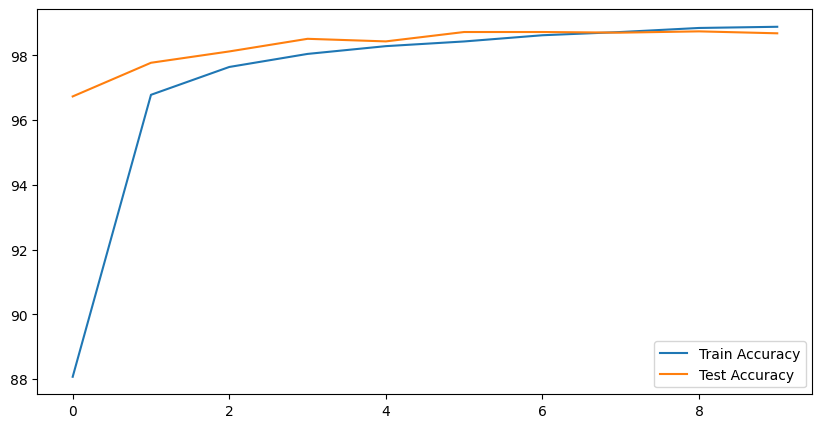

In [14]:
# 开始训练和测试，以及loss曲线和准确率曲线的可视化
if __name__ == "__main__":
    train_losses = []
    test_losses = []
    train_accs = []
    test_accs = []

    for epoch in range(10):
        train(epoch)
        test()

    # 可视化loss曲线
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(test_losses, label='Test Loss')
    plt.legend()
    plt.show()

    # 可视化准确率曲线
    plt.figure(figsize=(10, 5))
    plt.plot(train_accs, label='Train Accuracy')
    plt.plot(test_accs, label='Test Accuracy')
    plt.legend()
    plt.show()

### Residual Network

In [15]:
# 构建依赖
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import time
import random

In [16]:
# data prepare
batch_size = 64
transform = transforms.Compose([transforms.ToTensor(), 
                                transforms.Normalize((0.1307,), (0.3081,))])
# 训练集
train_dataset = datasets.MNIST(root='./dataset/mnist', train=True, download=False, transform=transform)
# 测试集
test_dataset = datasets.MNIST(root='./dataset/mnist', train=False, download=False, transform=transform)
# 数据加载器
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

print(f"size of train_loader: {train_loader.dataset.data.size()}")
print(f"size of test_loader: {test_loader.dataset.data.size()}")

size of train_loader: torch.Size([60000, 28, 28])
size of test_loader: torch.Size([10000, 28, 28])


In [ ]:
# model design
class ResidualBlock(torch.nn.Module):
    '''
    残差块(BasicBlock)
    输入通道数为in_channels, 输出通道数为out_channels, 步长为stride。
    包含两个 3x3 卷积层，每个卷积层后接 BatchNorm；最后与 shortcut 相加再 ReLU。
    '''
    def __init__(self, in_channels, out_channels, stride=1, downsample=None, block_name="block"):
        super(ResidualBlock, self).__init__()
        self.block_name = block_name    # block_name指残差块的名称

        self.conv1 = torch.nn.Conv2d(
            in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False
        )
        self.bn1 = torch.nn.BatchNorm2d(out_channels)
        self.relu = torch.nn.ReLU(inplace=True)

        self.conv2 = torch.nn.Conv2d(
            out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False
        )
        self.bn2 = torch.nn.BatchNorm2d(out_channels)

        # 若 stride!=1 或通道变化，需要 downsample 保证与主分支尺寸一致
        if downsample is None and (stride != 1 or in_channels != out_channels):
            # 解释：这里用1x1卷积（stride与主分支保持一致）作为下采样层，能够把输入张量同时匹配到目标的通道数和空间尺寸（高宽）。
            # 主分支如果有stride>1或通道变化，直接加和会size mismatch。1x1卷积stride=stride时，能实现：
            #   1）空间上等比例下采样，保证输出高宽和主分支一致
            #   2）变换通道数到out_channels，实现通道对齐
            # BatchNorm进一步保证数值分布和主分支同步
            self.downsample = torch.nn.Sequential(
                torch.nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                torch.nn.BatchNorm2d(out_channels),
            )
        else:
            self.downsample = downsample

    @staticmethod
    def _log(name, x, verbose):
        '''
        打印当前张量的形状和维度, verbose指是否打印
        '''
        if verbose:
            print(f"{name:<22} shape={tuple(x.shape)}, dim={x.dim()}")

    def forward(self, x, verbose=False):
        identity = x
        self._log(f"{self.block_name}.input", x, verbose)    # 打印当前张量的形状和维度

        out = self.conv1(x)
        self._log(f"{self.block_name}.conv1", out, verbose)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        self._log(f"{self.block_name}.conv2", out, verbose)
        out = self.bn2(out)

        if self.downsample is not None:
            identity = self.downsample(x)
            self._log(f"{self.block_name}.shortcut", identity, verbose)

        out += identity
        self._log(f"{self.block_name}.add", out, verbose)
        out = self.relu(out)
        self._log(f"{self.block_name}.out", out, verbose)
        return out


class Net(torch.nn.Module):
    def __init__(self, num_classes=10, print_shape_once=True):
        super(Net, self).__init__()
        self.conv1 = torch.nn.Conv2d(1, 16, kernel_size=5)
        self.conv2 = torch.nn.Conv2d(16, 32, kernel_size=5)
        self.mp = torch.nn.MaxPool2d(2)

        self.rblock1 = ResidualBlock(16, 16, stride=2, block_name="rblock1")    # 这里stride=2, 那么在ResidualBlock的初始化中, 原本的stride=1, 现在变为2
        self.rblock2 = ResidualBlock(32, 32, stride=2, block_name="rblock2")

        # 用全局池化避免手算 flatten 维度
        self.gap = torch.nn.AdaptiveAvgPool2d((1, 1))    # 全局池化层，将输入张量的高宽都池化到1*1
        self.fc = torch.nn.Linear(32, num_classes)

        # 只在第一次 forward 打印形状，避免训练日志过多
        self.print_shape_once = print_shape_once

    @staticmethod
    def _log(name, x, verbose):
        if verbose:
            print(f"{name:<22} shape={tuple(x.shape)}, dim={x.dim()}")

    def forward(self, x):
        verbose = self.print_shape_once
        self._log("input", x, verbose)    
        # input (64, 1, 28, 28), batch_size=64, 灰度图 1 通道，MNIST 尺寸 28x28

        x = self.conv1(x)
        self._log("conv1", x, verbose)
        # Conv2d(1,16,kernel=5,stride=1,padding=0)
        # conv1 (64, 16, 24, 24), batch_size=64, 灰度图 16 通道，MNIST 尺寸 24x24
        
        x = F.relu(x)    # 形状不变
        x = self.mp(x)    
        self._log("pool1", x, verbose)
        # MaxPool2d(2), pool1 -> (64, 16, 12, 12), 空间减半，通道不变

        x = self.rblock1(x, verbose=verbose)
        # ResidualBlock(16, 16, stride=2, block_name="rblock1")
        # rblock1.input -> (64, 16, 12, 12), 进入残差块前，形状还未变化
        # rblock1.conv1 -> (64, 16, 6, 6), 卷积核3x3, stride=2, padding=1, 卷积后, 空间减半, 通道不变
        # rblock1.bn1 -> (64, 16, 6, 6), 批归一化后，形状不变
        # rblock1.relu -> (64, 16, 6, 6), 激活函数后，形状不变
        # rblock1.conv2 -> (64, 16, 6, 6), 卷积核3x3, stride=1, padding=1, 卷积后，形状不变
        # rblock1.bn2 -> (64, 16, 6, 6), 批归一化后，形状不变
        
        x = self.conv2(x)
        self._log("conv2", x, verbose)
        # Conv2d(16,32,kernel=5,stride=1,padding=0)
        # conv2 -> (64,32,2,2)
        x = F.relu(x)    # 形状不变
        x = self.mp(x)    
        self._log("pool2", x, verbose)
        # MaxPool2d(2,2)，2 -> 1，通道不变
        # pool2 -> (64,32,1,1)

        x = self.rblock2(x, verbose=verbose)
        # ResidualBlock(32, 32, stride=2, block_name="rblock2")
        # rblock2.input -> (64,32,1,1), 进入残差块前，形状还未变化
        # rblock2.conv1 -> (64,32,1,1), 卷积核3x3, stride=2, padding=1, 卷积后, 空间减半, 通道不变
        # rblock2.bn1 -> (64,32,1,1), 批归一化后，形状不变
        # rblock2.relu -> (64,32,1,1), 激活函数后，形状不变
        # rblock2.conv2 -> (64,32,1,1), 卷积核3x3, stride=1, padding=1, 卷积后，形状不变
        # rblock2.bn2 -> (64,32,1,1), 批归一化后，形状不变

        x = self.gap(x)
        self._log("global_avg_pool", x, verbose)
        # 本来就 1x1，所以 全局池化 不改变尺寸（在更大特征图时会压到 1x1）
        # global_avg_pool -> (64,32,1,1)

        x = torch.flatten(x, 1)    # 展平操作，将张量展平为一维
        self._log("flatten", x, verbose)
        # flatten -> (64,32), 把每个样本的 32x1x1 拉平为长度 32 的向量

        x = self.fc(x)
        self._log("fc_out", x, verbose)
        # 全连接 Linear(32,10)，输出 10 类 logits

        if self.print_shape_once:
            self.print_shape_once = False

        return x


model = Net(print_shape_once=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

Net(
  (conv1): Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1))
  (mp): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (rblock1): ResidualBlock(
    (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (downsample): Sequential(
      (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(2, 2), bias=False)
      (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (rblock2): ResidualBlock(
    (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(32, eps=1e-05, momentu

In [26]:
# loss and optimizer
criterion = torch.nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.5)

In [27]:
# train cycle
def train(epoch):
    model.train()
    running_loss = 0.0    # 用于每200个batch打印
    epoch_loss = 0.0      # 用于记录整个epoch平均loss
    num_batches = 0
    train_correct = 0
    train_total = 0

    for batch_idx, data in enumerate(train_loader, 0):
        '''
        batch_idx 是当前批次索引, data 是当前批次的数据和标签
        (train_loader, 0) 表示从train_loader中获取数据, 从0开始计数
        '''
        inputs, labels = data    # 获取当前循环的索引批次对应的输入数据和标签
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()    # 每一次循环开始时，先进行梯度清零

        outputs = model(inputs)    # 将输入数据传入模型Net，得到输出
        loss = criterion(outputs, labels)    # 损失函数计算
        loss.backward()    # 计算完损失函数后，进行反向传播, 计算梯度
        optimizer.step()    # 计算完梯度后，进行参数更新

        running_loss += loss.item()    # 损失值累加到running_loss中
        epoch_loss += loss.item()
        num_batches += 1

        _, predicted = torch.max(outputs.data, dim=1)
        train_total += labels.size(0)    # 获取标签的数量作为训练的总数量
        train_correct += (predicted == labels).sum().item()

        # 每200个批次打印一次损失，查看依次训练的损失
        if batch_idx % 200 == 199:
            print(f"[epoch {epoch + 1}, batch {batch_idx + 1}] loss: {running_loss / 200}")
            running_loss = 0.0

    avg_train_loss = epoch_loss / num_batches
    train_losses.append(avg_train_loss)
    train_accs.append(100 * train_correct / train_total)

In [28]:
# test
def test():
    '''
    return: 预测结果
    '''
    model.eval()
    correct = 0.0
    total = 0.0
    test_loss = 0.0
    num_batches = 0    # 记录测试集的批次数量

    with torch.no_grad():    # 推理阶段不需要计算梯度
        for data in test_loader:    # 获取测试集中的数据，数据由28*28的灰度图像和对应的标签组成
            images, labels = data
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            loss = criterion(outputs, labels)
            test_loss += loss.item()
            num_batches += 1

            # 获取输出中最大概率的索引
            # dim = 1 沿着列的方向取最大值，即按行取最大值，即从第一行开始，取每一行的所有列中列的最大值
            # 返回最大值的索引和最大值
            _, predicted = torch.max(outputs.data, dim=1)
            total += labels.size(0)    # 获取标签的数量
            correct += (predicted == labels).sum().item()    # 计算预测正确的数量

    avg_test_loss = test_loss / num_batches
    avg_test_acc = 100 * correct / total
    test_losses.append(avg_test_loss)
    test_accs.append(avg_test_acc)
    print(f"Accuracy of the network on the 10000 test images: {avg_test_acc}%")

input                  shape=(64, 1, 28, 28), dim=4
conv1                  shape=(64, 16, 24, 24), dim=4
pool1                  shape=(64, 16, 12, 12), dim=4
rblock1.input          shape=(64, 16, 12, 12), dim=4
rblock1.conv1          shape=(64, 16, 6, 6), dim=4
rblock1.conv2          shape=(64, 16, 6, 6), dim=4
rblock1.shortcut       shape=(64, 16, 6, 6), dim=4
rblock1.add            shape=(64, 16, 6, 6), dim=4
rblock1.out            shape=(64, 16, 6, 6), dim=4
conv2                  shape=(64, 32, 2, 2), dim=4
pool2                  shape=(64, 32, 1, 1), dim=4
rblock2.input          shape=(64, 32, 1, 1), dim=4
rblock2.conv1          shape=(64, 32, 1, 1), dim=4
rblock2.conv2          shape=(64, 32, 1, 1), dim=4
rblock2.shortcut       shape=(64, 32, 1, 1), dim=4
rblock2.add            shape=(64, 32, 1, 1), dim=4
rblock2.out            shape=(64, 32, 1, 1), dim=4
global_avg_pool        shape=(64, 32, 1, 1), dim=4
flatten                shape=(64, 32), dim=2
fc_out                 shape=(

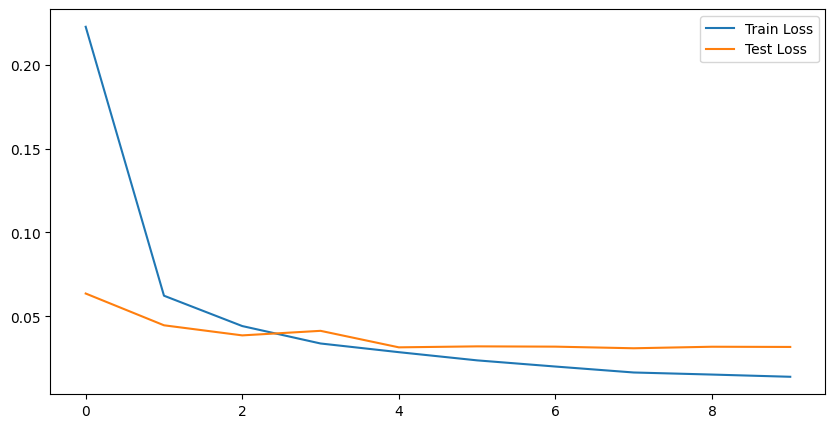

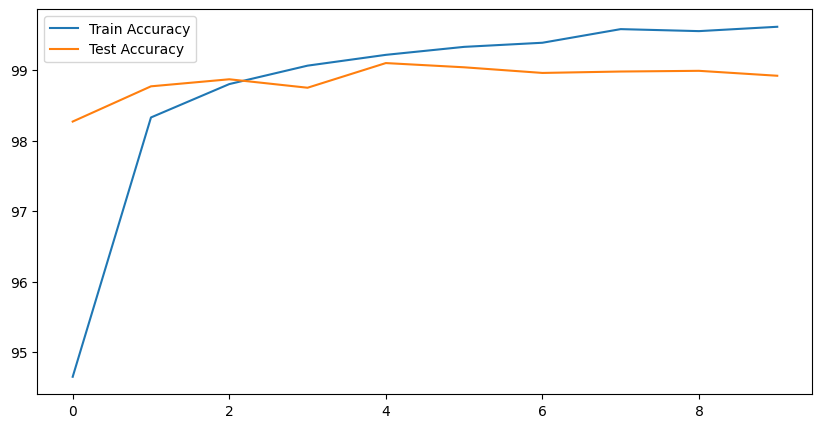

In [29]:
# 开始训练和测试，以及loss曲线和准确率曲线的可视化
if __name__ == "__main__":
    train_losses = []
    test_losses = []
    train_accs = []
    test_accs = []

    for epoch in range(10):
        train(epoch)
        test()

    # 可视化loss曲线
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(test_losses, label='Test Loss')
    plt.legend()
    plt.show()

    # 可视化准确率曲线
    plt.figure(figsize=(10, 5))
    plt.plot(train_accs, label='Train Accuracy')
    plt.plot(test_accs, label='Test Accuracy')
    plt.legend()
    plt.show()